# Renderer Profiling

Sweeps key rendering parameters and measures wall-clock time per frame.
Each measurement warms up the JIT cache, then averages over several runs.
Both **forward** (render) and **backward** (gradient) passes are timed.

> Note: `aa_samples` is a `raymarch`-only parameter and is not available in
> the differentiable `functionalize_render` path, so it is not profiled here.

Sweeps covered:
1. **Image resolution** — pixels × pixels
2. **`max_steps`** — ray-march iterations
3. **`shadow_steps`** — shadow-ray iterations
4. **Scene complexity** — number of SDF primitives

In [14]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxcad import functionalize_render
from jaxcad.extraction import extract_parameters
from jaxcad.geometry import Scalar, Vector
from jaxcad.render import Camera, Material, Scene
from jaxcad.sdf import Box, Sphere, Translate, Union

print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


In [15]:
# ── Reference scene ───────────────────────────────────────────────────────────
# 8-primitive scene used as the baseline across all sweeps.


def build_scene(n_primitives: int = 8) -> Scene:
    """Build a Union of n_primitives spheres/boxes arranged in a ring."""
    import math

    mats = [
        Material(color=[0.8, 0.2, 0.2], roughness=0.4),
        Material(color=[0.2, 0.6, 0.9], roughness=0.3),
        Material(color=[0.2, 0.8, 0.3], roughness=0.6),
        Material(color=[0.9, 0.7, 0.1], roughness=0.2),
    ]

    parts = []
    for i in range(n_primitives):
        angle = 2 * math.pi * i / n_primitives
        r = 1.4
        pos = Vector([r * math.cos(angle), 0.0, r * math.sin(angle)], free=False)
        mat = mats[i % len(mats)]
        if i % 2 == 0:
            parts.append(Translate(Sphere(radius=0.55, material=mat), pos))
        else:
            parts.append(Translate(Box(size=[0.7, 0.7, 0.7], material=mat), pos))

    geometry = Union(tuple(parts), smoothness=0.1)

    camera = Camera(
        camera_pos=Vector([0.0, 3.5, 6.0], free=False),
        look_at=Vector([0.0, 0.0, 0.0], free=False),
        fov=Scalar(0.55, free=False),
    )
    return Scene(
        geometry,
        camera,
        bg_color=Vector([0.08, 0.10, 0.18], free=False),
        light_dirs=[
            Vector([1.0, 2.0, 1.5], free=False),
            Vector([-1.0, 0.5, -0.8], free=False),
        ],
        light_colors=[
            Vector([1.0, 0.92, 0.75], free=False),
            Vector([0.25, 0.35, 0.65], free=False),
        ],
    )


REF_SCENE = build_scene(8)
REF_PARAMS, _, _ = extract_parameters(REF_SCENE)
print(f"Reference scene: {len(REF_PARAMS)} free params")

Reference scene: 0 free params


In [16]:
# ── Timing utility ────────────────────────────────────────────────────────────


def bench(fn, warmup: int = 1, repeat: int = 5):
    """Time a zero-argument callable.

    The first call is timed to capture JIT compile + first-run overhead.
    Then `repeat` steady-state calls are measured.

    Returns:
        (mean_ms, std_ms, jit_ms)
        mean_ms — average steady-state call time
        std_ms  — standard deviation
        jit_ms  — estimated JIT compile overhead (first_call − mean_steady)
    """
    # Timed first call: XLA compilation + first execution
    t0 = time.perf_counter()
    jax.block_until_ready(fn())
    first_ms = (time.perf_counter() - t0) * 1e3

    # Extra warmup passes (warmup=1 usually sufficient for JAX/XLA)
    for _ in range(warmup - 1):
        jax.block_until_ready(fn())

    # Steady-state timing
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        jax.block_until_ready(fn())
        times.append((time.perf_counter() - t0) * 1e3)

    mean_ms = float(np.mean(times))
    std_ms = float(np.std(times))
    jit_ms = max(first_ms - mean_ms, 0.0)
    return mean_ms, std_ms, jit_ms


def make_render_fns(scene, params, resolution, **kwargs):
    """Compile and return (fwd_fn, grad_fn) ready for bench().

    fwd_fn  — renders the scene: () → image
    grad_fn — computes value + gradients w.r.t. params: () → (loss, grads)
              loss = mean pixel value (proxy scalar for profiling)
    """
    render = functionalize_render(scene, **kwargs)
    fwd = jax.jit(lambda: render(params, resolution=resolution))

    def loss_fn(p):
        return jnp.mean(render(p, resolution=resolution))

    grad = jax.jit(lambda: jax.value_and_grad(loss_fn)(params))
    return fwd, grad


def grouped_bar_chart(
    ax, labels, fwd_means, fwd_stds, grad_means, grad_stds, xlabel, ylabel="ms / call", title=""
):
    xs = np.arange(len(labels))
    w = 0.38
    ax.bar(
        xs - w / 2,
        fwd_means,
        yerr=fwd_stds,
        width=w,
        capsize=3,
        color="steelblue",
        alpha=0.85,
        label="forward",
    )
    ax.bar(
        xs + w / 2,
        grad_means,
        yerr=grad_stds,
        width=w,
        capsize=3,
        color="tomato",
        alpha=0.85,
        label="grad",
    )
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.35)
    top = max(max(fwd_means), max(grad_means))
    for x, m in zip(xs - w / 2, fwd_means):
        ax.text(x, m + top * 0.01, f"{m:.1f}", ha="center", fontsize=7, color="steelblue")
    for x, m in zip(xs + w / 2, grad_means):
        ax.text(x, m + top * 0.01, f"{m:.1f}", ha="center", fontsize=7, color="tomato")


def jit_bar_chart(ax, labels, fwd_jit, grad_jit, xlabel, title="JIT compile time"):
    """Bar chart of estimated JIT compile overhead (first_call − steady_state)."""
    xs = np.arange(len(labels))
    w = 0.38
    ax.bar(xs - w / 2, fwd_jit, width=w, color="steelblue", alpha=0.55, label="fwd JIT")
    ax.bar(xs + w / 2, grad_jit, width=w, color="tomato", alpha=0.55, label="grad JIT")
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("ms")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.35)
    top = max(max(fwd_jit, default=0), max(grad_jit, default=0), 1)
    for x, m in zip(xs - w / 2, fwd_jit):
        ax.text(x, m + top * 0.01, f"{m:.0f}", ha="center", fontsize=7, color="steelblue")
    for x, m in zip(xs + w / 2, grad_jit):
        ax.text(x, m + top * 0.01, f"{m:.0f}", ha="center", fontsize=7, color="tomato")

## 1. Image Resolution

Resolution doubles each step: 32 → 64 → 128 → 256 → 512.  
Each new resolution triggers a JIT retrace (output shape changes), so warmup is per-resolution.

In [ ]:
RESOLUTIONS = [32, 64, 128, 256, 512]
RENDER_KWARGS = {"max_steps": 32, "shadow_steps": 12, "shadow_hardness": 6.0, "gamma": 2.2}

res_fwd_means, res_fwd_stds, res_fwd_jit = [], [], []
res_grad_means, res_grad_stds, res_grad_jit = [], [], []

for px in RESOLUTIONS:
    fwd, grad = make_render_fns(REF_SCENE, REF_PARAMS, (px, px), **RENDER_KWARGS)
    mf, sf, jf = bench(fwd)
    mg, sg, jg = bench(grad)
    res_fwd_means.append(mf)
    res_fwd_stds.append(sf)
    res_fwd_jit.append(jf)
    res_grad_means.append(mg)
    res_grad_stds.append(sg)
    res_grad_jit.append(jg)
    print(
        f"  {px:4d}×{px:<4d}  fwd={mf:7.1f}±{sf:.1f} ms (JIT {jf:.0f})   grad={mg:7.1f}±{sg:.1f} ms (JIT {jg:.0f})"
    )

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
grouped_bar_chart(
    axes[0],
    [f"{p}×{p}" for p in RESOLUTIONS],
    res_fwd_means,
    res_fwd_stds,
    res_grad_means,
    res_grad_stds,
    xlabel="Resolution",
    title="Render time vs resolution",
)
axes[1].errorbar(
    RESOLUTIONS,
    res_fwd_means,
    yerr=res_fwd_stds,
    fmt="o-",
    capsize=4,
    color="steelblue",
    label="forward",
)
axes[1].errorbar(
    RESOLUTIONS,
    res_grad_means,
    yerr=res_grad_stds,
    fmt="s-",
    capsize=4,
    color="tomato",
    label="grad",
)
ref = res_fwd_means[0] * (np.array(RESOLUTIONS) / RESOLUTIONS[0]) ** 2
axes[1].plot(RESOLUTIONS, ref, "k--", alpha=0.4, label="O(N²)")
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("Resolution (px)")
axes[1].set_ylabel("ms / call")
axes[1].set_title("Log-log scaling")
axes[1].legend()
axes[1].grid(True, alpha=0.35)
jit_bar_chart(
    axes[2],
    [f"{p}×{p}" for p in RESOLUTIONS],
    res_fwd_jit,
    res_grad_jit,
    xlabel="Resolution",
    title="JIT compile time vs resolution",
)
plt.tight_layout()
plt.show()

## 2. Ray-march Steps (`max_steps`)

Each extra step is one SDF evaluation per pixel.  Expect roughly linear scaling.

  max_steps=   4  fwd=    4.2±0.6 ms (JIT 3492)   grad=    3.8±0.2 ms (JIT 3643)
  max_steps=   8  fwd=    3.2±0.4 ms (JIT 3525)   grad=    4.1±0.8 ms (JIT 3902)
  max_steps=  16  fwd=    4.7±0.4 ms (JIT 3638)   grad=    4.3±0.4 ms (JIT 3670)
  max_steps=  32  fwd=    9.4±2.2 ms (JIT 3593)   grad=    6.4±0.4 ms (JIT 3714)
  max_steps=  64  fwd=    8.2±0.9 ms (JIT 3713)   grad=    9.6±0.7 ms (JIT 3777)
  max_steps= 128  fwd=   18.4±1.4 ms (JIT 3803)   grad=   17.7±5.3 ms (JIT 3534)


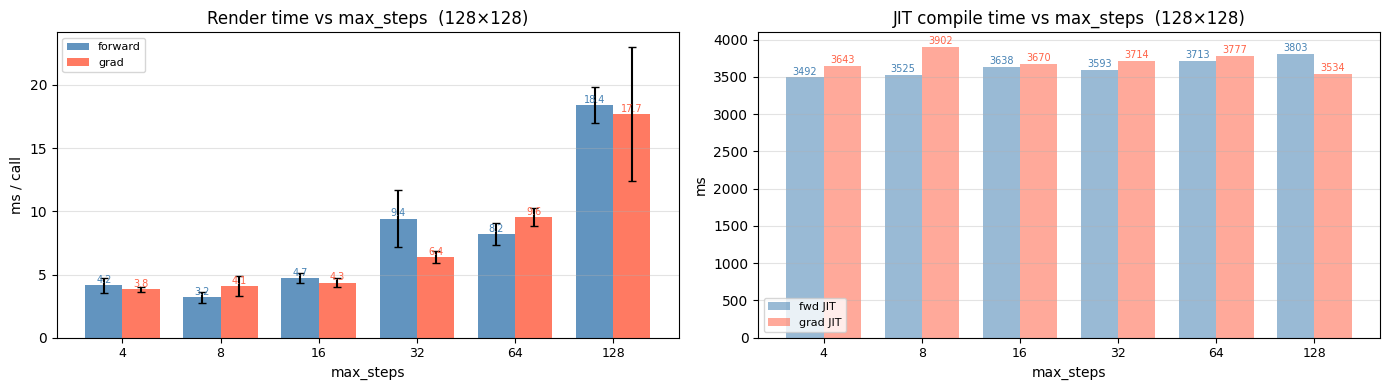

In [5]:
MAX_STEPS_VALS = [4, 8, 16, 32, 64, 128]
REF_RES = (128, 128)

ms_fwd_means, ms_fwd_stds, ms_fwd_jit = [], [], []
ms_grad_means, ms_grad_stds, ms_grad_jit = [], [], []

for steps in MAX_STEPS_VALS:
    fwd, grad = make_render_fns(
        REF_SCENE,
        REF_PARAMS,
        REF_RES,
        max_steps=steps,
        shadow_steps=12,
        shadow_hardness=6.0,
        gamma=2.2,
    )
    mf, sf, jf = bench(fwd)
    mg, sg, jg = bench(grad)
    ms_fwd_means.append(mf)
    ms_fwd_stds.append(sf)
    ms_fwd_jit.append(jf)
    ms_grad_means.append(mg)
    ms_grad_stds.append(sg)
    ms_grad_jit.append(jg)
    print(
        f"  max_steps={steps:4d}  fwd={mf:7.1f}±{sf:.1f} ms (JIT {jf:.0f})   grad={mg:7.1f}±{sg:.1f} ms (JIT {jg:.0f})"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
grouped_bar_chart(
    axes[0],
    [str(s) for s in MAX_STEPS_VALS],
    ms_fwd_means,
    ms_fwd_stds,
    ms_grad_means,
    ms_grad_stds,
    xlabel="max_steps",
    title=f"Render time vs max_steps  ({REF_RES[0]}×{REF_RES[1]})",
)
jit_bar_chart(
    axes[1],
    [str(s) for s in MAX_STEPS_VALS],
    ms_fwd_jit,
    ms_grad_jit,
    xlabel="max_steps",
    title=f"JIT compile time vs max_steps  ({REF_RES[0]}×{REF_RES[1]})",
)
plt.tight_layout()
plt.show()

## 3. Shadow Steps (`shadow_steps`)

Soft shadows cast one shadow ray per lit pixel.  `shadow_steps=0` disables shadows entirely.

  shadow_steps=   0  fwd=    4.0±0.4 ms (JIT 4267)   grad=    1.9±0.2 ms (JIT 3419)
  shadow_steps=   4  fwd=    9.1±1.8 ms (JIT 3646)   grad=    8.8±1.4 ms (JIT 3933)
  shadow_steps=   8  fwd=   11.6±1.7 ms (JIT 3773)   grad=    6.7±3.9 ms (JIT 3711)
  shadow_steps=  16  fwd=   11.7±1.8 ms (JIT 3508)   grad=   11.3±1.6 ms (JIT 3803)
  shadow_steps=  32  fwd=   12.9±2.4 ms (JIT 3641)   grad=   10.9±2.6 ms (JIT 3622)
  shadow_steps=  64  fwd=   14.5±1.2 ms (JIT 3532)   grad=   18.8±5.9 ms (JIT 3545)


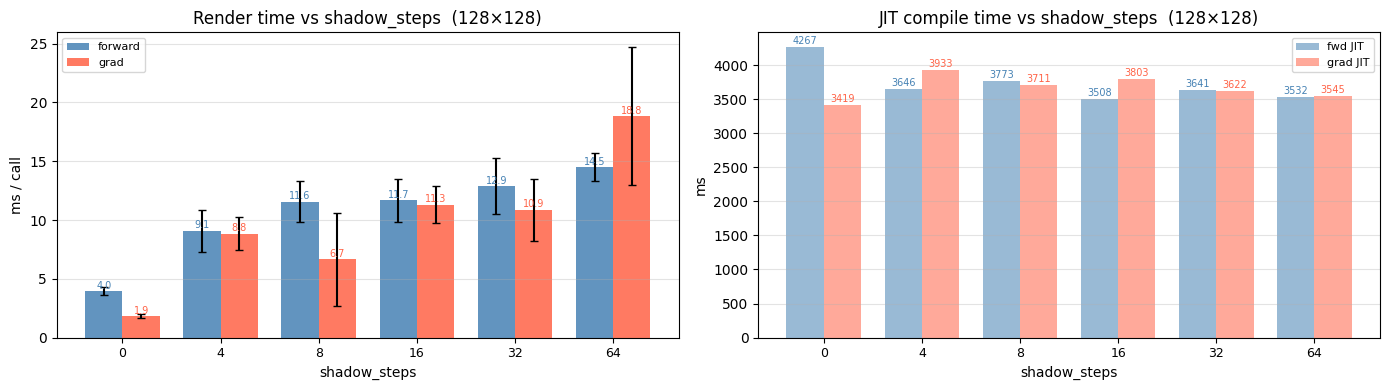

In [6]:
SHADOW_STEPS_VALS = [0, 4, 8, 16, 32, 64]

sh_fwd_means, sh_fwd_stds, sh_fwd_jit = [], [], []
sh_grad_means, sh_grad_stds, sh_grad_jit = [], [], []

for steps in SHADOW_STEPS_VALS:
    fwd, grad = make_render_fns(
        REF_SCENE,
        REF_PARAMS,
        REF_RES,
        max_steps=32,
        shadow_steps=steps,
        shadow_hardness=6.0,
        gamma=2.2,
    )
    mf, sf, jf = bench(fwd)
    mg, sg, jg = bench(grad)
    sh_fwd_means.append(mf)
    sh_fwd_stds.append(sf)
    sh_fwd_jit.append(jf)
    sh_grad_means.append(mg)
    sh_grad_stds.append(sg)
    sh_grad_jit.append(jg)
    print(
        f"  shadow_steps={steps:4d}  fwd={mf:7.1f}±{sf:.1f} ms (JIT {jf:.0f})   grad={mg:7.1f}±{sg:.1f} ms (JIT {jg:.0f})"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
grouped_bar_chart(
    axes[0],
    [str(s) for s in SHADOW_STEPS_VALS],
    sh_fwd_means,
    sh_fwd_stds,
    sh_grad_means,
    sh_grad_stds,
    xlabel="shadow_steps",
    title=f"Render time vs shadow_steps  ({REF_RES[0]}×{REF_RES[1]})",
)
jit_bar_chart(
    axes[1],
    [str(s) for s in SHADOW_STEPS_VALS],
    sh_fwd_jit,
    sh_grad_jit,
    xlabel="shadow_steps",
    title=f"JIT compile time vs shadow_steps  ({REF_RES[0]}×{REF_RES[1]})",
)
plt.tight_layout()
plt.show()

## 4. Scene Complexity (number of primitives)

Each primitive adds one SDF evaluation to the Union.  The cost depends on whether XLA
fuses or unrolls the loop — this sweep makes that visible.

  n_primitives=  1  fwd=    5.7±2.3 ms (JIT 771)   grad=    5.8±1.0 ms (JIT 654)
  n_primitives=  2  fwd=    5.8±0.6 ms (JIT 1487)   grad=    7.6±2.4 ms (JIT 1097)
  n_primitives=  4  fwd=    5.6±0.9 ms (JIT 2345)   grad=    9.6±1.2 ms (JIT 1706)
  n_primitives=  8  fwd=    8.9±1.0 ms (JIT 3921)   grad=   13.6±1.8 ms (JIT 3843)
  n_primitives= 16  fwd=    9.2±0.9 ms (JIT 15876)   grad=    9.8±1.9 ms (JIT 13922)
  n_primitives= 32  fwd=    9.1±1.8 ms (JIT 47728)   grad=    9.8±2.0 ms (JIT 45656)


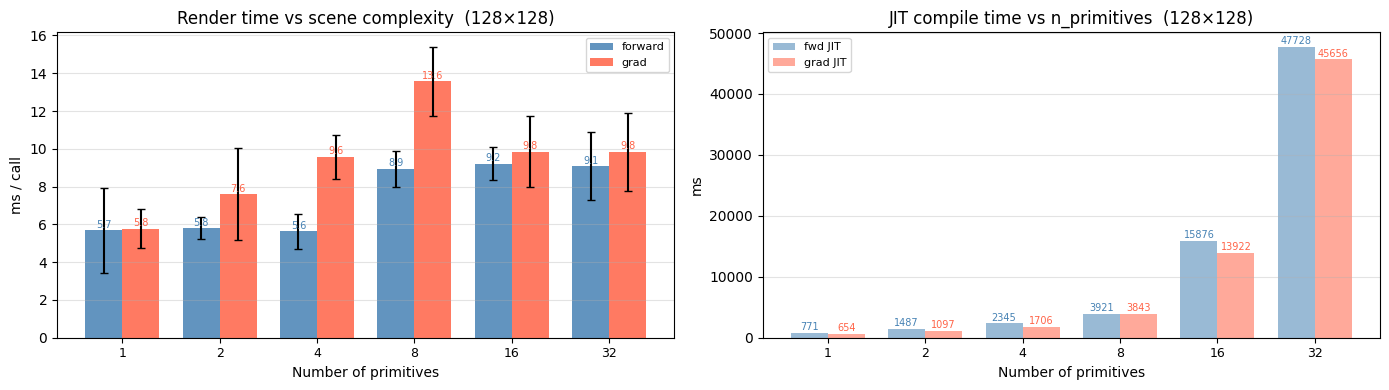

In [7]:
N_PRIMS = [1, 2, 4, 8, 16, 32]

cx_fwd_means, cx_fwd_stds, cx_fwd_jit = [], [], []
cx_grad_means, cx_grad_stds, cx_grad_jit = [], [], []

for n in N_PRIMS:
    scene_n = build_scene(n)
    params_n, _, _ = extract_parameters(scene_n)
    fwd, grad = make_render_fns(
        scene_n, params_n, REF_RES, max_steps=32, shadow_steps=12, shadow_hardness=6.0, gamma=2.2
    )
    mf, sf, jf = bench(fwd)
    mg, sg, jg = bench(grad)
    cx_fwd_means.append(mf)
    cx_fwd_stds.append(sf)
    cx_fwd_jit.append(jf)
    cx_grad_means.append(mg)
    cx_grad_stds.append(sg)
    cx_grad_jit.append(jg)
    print(
        f"  n_primitives={n:3d}  fwd={mf:7.1f}±{sf:.1f} ms (JIT {jf:.0f})   grad={mg:7.1f}±{sg:.1f} ms (JIT {jg:.0f})"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
grouped_bar_chart(
    axes[0],
    [str(n) for n in N_PRIMS],
    cx_fwd_means,
    cx_fwd_stds,
    cx_grad_means,
    cx_grad_stds,
    xlabel="Number of primitives",
    title=f"Render time vs scene complexity  ({REF_RES[0]}×{REF_RES[1]})",
)
jit_bar_chart(
    axes[1],
    [str(n) for n in N_PRIMS],
    cx_fwd_jit,
    cx_grad_jit,
    xlabel="Number of primitives",
    title=f"JIT compile time vs n_primitives  ({REF_RES[0]}×{REF_RES[1]})",
)
plt.tight_layout()
plt.show()

## Summary

Normalised cost relative to the cheapest setting in each sweep.

## 5. `fd_normals` — Finite-difference vs Analytic Normals

`fd_normals=False` (default) computes surface normals via `jax.grad(sdf)(point)`.
Inside `jax.grad(loss)` this triggers **2nd-order AD**, which is expensive and produces
NaN at hard-min boundaries (`smoothness=0`).

`fd_normals=True` replaces normal computation with central finite differences
(6 extra SDF evaluations per pixel).  Cheaper in the backward pass, NaN-free with any
Union smoothness, and visually indistinguishable at the default `eps=1e-4`.

### 5a. Basic comparison

In [ ]:
FD_CONFIGS = [
    ("analytic\n(fd_normals=False)", {"fd_normals": False}),
    ("finite-diff\n(fd_normals=True)", {"fd_normals": True}),
]

fd_fwd_means, fd_fwd_stds, fd_fwd_jit = [], [], []
fd_grad_means, fd_grad_stds, fd_grad_jit = [], [], []

for label, kwargs in FD_CONFIGS:
    fwd, grad = make_render_fns(
        REF_SCENE,
        REF_PARAMS,
        REF_RES,
        max_steps=32,
        shadow_steps=12,
        shadow_hardness=6.0,
        gamma=2.2,
        **kwargs,
    )
    mf, sf, jf = bench(fwd)
    mg, sg, jg = bench(grad)
    fd_fwd_means.append(mf)
    fd_fwd_stds.append(sf)
    fd_fwd_jit.append(jf)
    fd_grad_means.append(mg)
    fd_grad_stds.append(sg)
    fd_grad_jit.append(jg)
    print(
        f"  {label.replace(chr(10), ' '):<40}  fwd={mf:7.1f}±{sf:.1f} ms (JIT {jf:.0f})   grad={mg:7.1f}±{sg:.1f} ms (JIT {jg:.0f})"
    )

print(f"\n  steady-state grad speedup (fd vs analytic): {fd_grad_means[0] / fd_grad_means[1]:.2f}×")
print(
    f"  JIT speedup (fd vs analytic):  fwd {fd_fwd_jit[0] / max(fd_fwd_jit[1], 1):.1f}×   grad {fd_grad_jit[0] / max(fd_grad_jit[1], 1):.1f}×"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
grouped_bar_chart(
    axes[0],
    [lbl.split("\n")[0] for lbl, _ in FD_CONFIGS],
    fd_fwd_means,
    fd_fwd_stds,
    fd_grad_means,
    fd_grad_stds,
    xlabel="Normal mode",
    title=f"Steady-state time  ({REF_RES[0]}×{REF_RES[1]})",
)
jit_bar_chart(
    axes[1],
    [lbl.split("\n")[0] for lbl, _ in FD_CONFIGS],
    fd_fwd_jit,
    fd_grad_jit,
    xlabel="Normal mode",
    title=f"JIT compile time  ({REF_RES[0]}×{REF_RES[1]})",
)
plt.tight_layout()
plt.show()

### 5b. Speedup vs `max_steps` and `n_primitives`

With `fd_normals=False`, computing surface normals inside `jax.grad(loss)` requires
**2nd-order autodiff** — differentiating through `jax.grad(sdf)(pos)`.  The cost scales
with the scan depth (`max_steps`) and the SDF tree size (`n_primitives`).

With `fd_normals=True` the normal is 6 FD SDF evaluations — constant per pixel,
independent of scene depth.  The **speedup therefore grows** with complexity.

### 5c. Visual quality

`fd_normals=True` is visually indistinguishable from analytic normals at the default
`eps=1e-4` (≈ 0.1 mm at unit-scale scenes).  The difference image below quantifies
the per-pixel error.

max_steps sweep (grad only):
  steps=   8  analytic=    4.9 ms   fd=    5.3 ms  speedup=0.92×
  steps=  16  analytic=    6.8 ms   fd=    6.4 ms  speedup=1.06×
  steps=  32  analytic=    9.5 ms   fd=   11.7 ms  speedup=0.81×
  steps=  64  analytic=   13.7 ms   fd=   12.4 ms  speedup=1.10×
  steps= 128  analytic=   23.5 ms   fd=   25.2 ms  speedup=0.93×

n_primitives sweep (grad only):
  n=  2  analytic=    9.2 ms   fd=    8.1 ms  speedup=1.14×
  n=  4  analytic=   17.4 ms   fd=   19.5 ms  speedup=0.89×
  n=  8  analytic=    8.9 ms   fd=   10.1 ms  speedup=0.88×
  n= 16  analytic=   10.0 ms   fd=   11.6 ms  speedup=0.87×
  n= 32  analytic=    2.3 ms   fd=   32.4 ms  speedup=0.07×


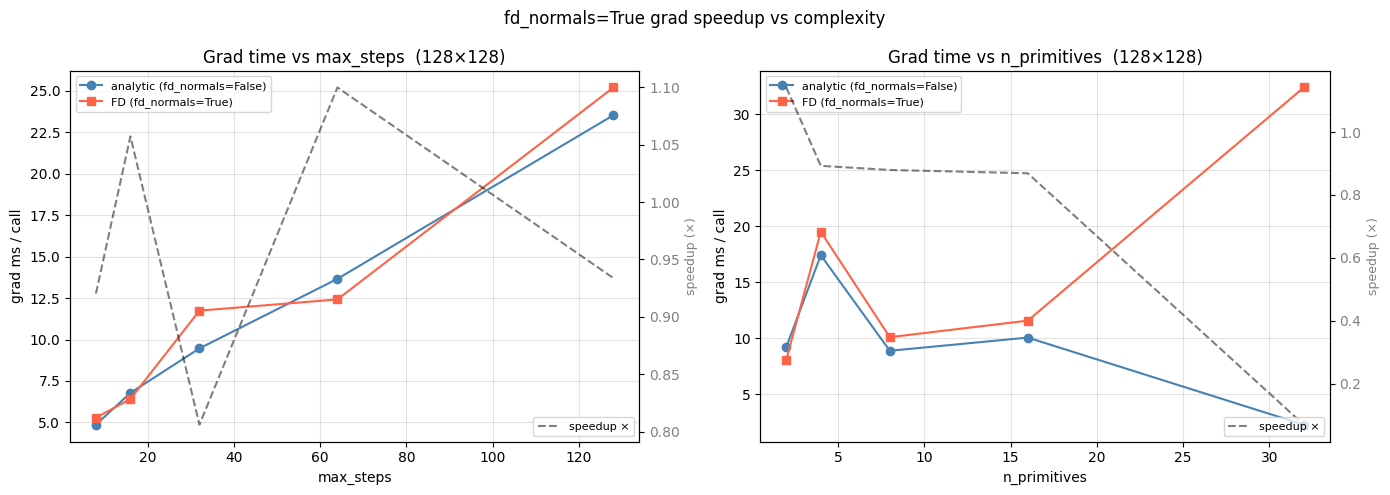

In [9]:
# How fd_normals speedup scales with max_steps and scene complexity.
# Analytic normals require 2nd-order AD through the scan loop and SDF tree,
# so cost grows with both. FD normals are 6 SDF evals per pixel — fixed.

FD_STEPS_SWEEP = [8, 16, 32, 64, 128]
FD_PRIM_SWEEP = [2, 4, 8, 16, 32]

print("max_steps sweep (grad only):")
fd_ad_by_steps, fd_fd_by_steps = [], []
for steps in FD_STEPS_SWEEP:
    _, grad_ad = make_render_fns(
        REF_SCENE,
        REF_PARAMS,
        (128, 128),
        max_steps=steps,
        shadow_steps=12,
        shadow_hardness=6.0,
        gamma=2.2,
        fd_normals=False,
    )
    _, grad_fd = make_render_fns(
        REF_SCENE,
        REF_PARAMS,
        (128, 128),
        max_steps=steps,
        shadow_steps=12,
        shadow_hardness=6.0,
        gamma=2.2,
        fd_normals=True,
    )
    mad, _, _ = bench(grad_ad)
    mfd, _, _ = bench(grad_fd)
    fd_ad_by_steps.append(mad)
    fd_fd_by_steps.append(mfd)
    print(f"  steps={steps:4d}  analytic={mad:7.1f} ms   fd={mfd:7.1f} ms  speedup={mad/mfd:.2f}×")

print("\nn_primitives sweep (grad only):")
fd_ad_by_prims, fd_fd_by_prims = [], []
for n in FD_PRIM_SWEEP:
    scene_n = build_scene(n)
    params_n, _, _ = extract_parameters(scene_n)
    _, grad_ad = make_render_fns(
        scene_n,
        params_n,
        (128, 128),
        max_steps=32,
        shadow_steps=12,
        shadow_hardness=6.0,
        gamma=2.2,
        fd_normals=False,
    )
    _, grad_fd = make_render_fns(
        scene_n,
        params_n,
        (128, 128),
        max_steps=32,
        shadow_steps=12,
        shadow_hardness=6.0,
        gamma=2.2,
        fd_normals=True,
    )
    mad, _, _ = bench(grad_ad)
    mfd, _, _ = bench(grad_fd)
    fd_ad_by_prims.append(mad)
    fd_fd_by_prims.append(mfd)
    print(f"  n={n:3d}  analytic={mad:7.1f} ms   fd={mfd:7.1f} ms  speedup={mad/mfd:.2f}×")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, xs, ad, fd, xlabel in [
    (axes[0], FD_STEPS_SWEEP, fd_ad_by_steps, fd_fd_by_steps, "max_steps"),
    (axes[1], FD_PRIM_SWEEP, fd_ad_by_prims, fd_fd_by_prims, "n_primitives"),
]:
    ax.plot(xs, ad, "o-", color="steelblue", label="analytic (fd_normals=False)", zorder=3)
    ax.plot(xs, fd, "s-", color="tomato", label="FD (fd_normals=True)", zorder=3)
    ax2 = ax.twinx()
    speedups = [a / max(b, 0.1) for a, b in zip(ad, fd)]
    ax2.plot(xs, speedups, "k--", alpha=0.5, label="speedup ×")
    ax2.set_ylabel("speedup (×)", color="gray", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="gray")
    ax2.legend(loc="lower right", fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("grad ms / call")
    ax.set_title(f"Grad time vs {xlabel}  (128×128)")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.35)

plt.suptitle("fd_normals=True grad speedup vs complexity", fontsize=12)
plt.tight_layout()
plt.show()

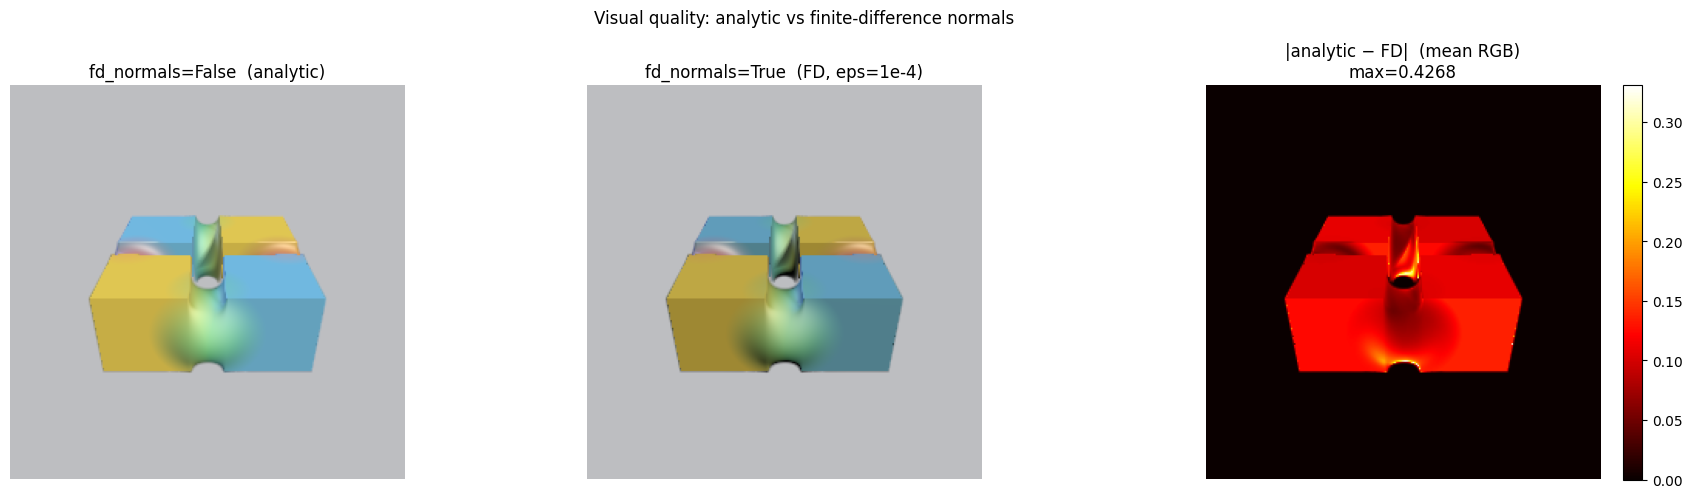

Max pixel difference: 0.42681   Mean: 0.022764


In [10]:
# Visual quality: analytic vs fd normals — should look identical at eps=1e-4.
render_ad = functionalize_render(
    REF_SCENE, max_steps=48, shadow_steps=16, shadow_hardness=6.0, gamma=2.2, fd_normals=False
)
render_fd = functionalize_render(
    REF_SCENE, max_steps=48, shadow_steps=16, shadow_hardness=6.0, gamma=2.2, fd_normals=True
)

img_ad = jax.jit(lambda: render_ad(REF_PARAMS, resolution=(256, 256)))()
img_fd = jax.jit(lambda: render_fd(REF_PARAMS, resolution=(256, 256)))()
diff = jnp.abs(img_ad - img_fd)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(np.array(img_ad), vmin=0, vmax=1)
axes[0].set_title("fd_normals=False  (analytic)")
axes[0].axis("off")
axes[1].imshow(np.array(img_fd), vmin=0, vmax=1)
axes[1].set_title("fd_normals=True  (FD, eps=1e-4)")
axes[1].axis("off")
im = axes[2].imshow(np.array(diff).mean(axis=-1), cmap="hot", vmin=0)
axes[2].set_title(f"|analytic − FD|  (mean RGB)\nmax={float(diff.max()):.4f}")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.suptitle("Visual quality: analytic vs finite-difference normals", fontsize=12)
plt.tight_layout()
plt.show()
print(f"Max pixel difference: {float(diff.max()):.5f}   Mean: {float(diff.mean()):.6f}")

---

## 6. Perfetto Trace

`jax.profiler.trace()` writes a Perfetto-compatible protobuf trace to disk.
Load it at **https://ui.perfetto.dev** to see individual XLA ops, kernel launch
latencies, and memory transfers broken down by name.

The cells below capture three traces:

| File | What it shows |
|------|--------------|
| `trace_ref/` | Reference render (128×128, 32 steps) — baseline breakdown |
| `trace_hires/` | High-res render (512×512) — how kernel shapes change |
| `trace_steps/` | Many march steps (128) — how the step loop unrolls |

`jax.named_call` wraps sub-expressions with human-readable names that appear
as spans in the Perfetto timeline.

In [ ]:
import os

TRACE_ROOT = "/tmp/jaxcad_profile"


def capture_trace(name: str, fn, n_iter: int = 5):
    """Warm up fn, then capture a Perfetto trace for n_iter calls."""
    trace_dir = os.path.join(TRACE_ROOT, name)
    for _ in range(3):
        jax.block_until_ready(fn())
    with jax.profiler.trace(trace_dir):
        for _ in range(n_iter):
            jax.block_until_ready(fn())
    print(f"  ✓ {name:<28}  →  {trace_dir}")
    return trace_dir


print("Capturing Perfetto traces (fwd + grad per config)...")
print(f"Output root: {TRACE_ROOT}\n")

configs = [
    ("ref_fwd", {"resolution": (128, 128), "max_steps": 32, "shadow_steps": 12}, "fwd"),
    ("ref_grad", {"resolution": (128, 128), "max_steps": 32, "shadow_steps": 12}, "grad"),
    ("hires_fwd", {"resolution": (512, 512), "max_steps": 32, "shadow_steps": 12}, "fwd"),
    ("hires_grad", {"resolution": (512, 512), "max_steps": 32, "shadow_steps": 12}, "grad"),
    ("steps_fwd", {"resolution": (128, 128), "max_steps": 128, "shadow_steps": 12}, "fwd"),
    ("steps_grad", {"resolution": (128, 128), "max_steps": 128, "shadow_steps": 12}, "grad"),
]

trace_paths = {}
for name, cfg, mode in configs:
    res = cfg.pop("resolution")
    fwd, grad = make_render_fns(REF_SCENE, REF_PARAMS, res, shadow_hardness=6.0, gamma=2.2, **cfg)
    fn = fwd if mode == "fwd" else grad
    trace_paths[name] = capture_trace(name, fn)

print("\nOpen each trace at https://ui.perfetto.dev  (File → Open trace file)")
print("Compare *_fwd vs *_grad to see the backward-pass overhead per config.")

In [ ]:
sweeps = [
    (
        [f"{p}×{p}" for p in RESOLUTIONS],
        res_fwd_means,
        res_fwd_stds,
        res_grad_means,
        res_grad_stds,
        res_fwd_jit,
        res_grad_jit,
        "Resolution",
    ),
    (
        [str(s) for s in MAX_STEPS_VALS],
        ms_fwd_means,
        ms_fwd_stds,
        ms_grad_means,
        ms_grad_stds,
        ms_fwd_jit,
        ms_grad_jit,
        "max_steps",
    ),
    (
        [str(s) for s in SHADOW_STEPS_VALS],
        sh_fwd_means,
        sh_fwd_stds,
        sh_grad_means,
        sh_grad_stds,
        sh_fwd_jit,
        sh_grad_jit,
        "shadow_steps",
    ),
    (
        [str(n) for n in N_PRIMS],
        cx_fwd_means,
        cx_fwd_stds,
        cx_grad_means,
        cx_grad_stds,
        cx_fwd_jit,
        cx_grad_jit,
        "n_primitives",
    ),
    (
        ["analytic", "fd"],
        fd_fwd_means,
        fd_fwd_stds,
        fd_grad_means,
        fd_grad_stds,
        fd_fwd_jit,
        fd_grad_jit,
        "fd_normals",
    ),
]

# ── Normalised steady-state cost ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (labels, fm, fs, gm, gs, _fj, _gj, xlabel) in zip(axes, sweeps):
    norm = fm[0] if fm[0] > 0 else 1.0
    grouped_bar_chart(
        ax,
        labels,
        [m / norm for m in fm],
        [s / norm for s in fs],
        [m / norm for m in gm],
        [s / norm for s in gs],
        xlabel=xlabel,
        ylabel="relative cost",
        title=xlabel,
    )
plt.suptitle("Normalised cost per sweep  (blue=forward, red=grad)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── JIT compile time ──────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 5, figsize=(22, 4))
for ax, (labels, _fm, _fs, _gm, _gs, fj, gj, xlabel) in zip(axes2, sweeps):
    jit_bar_chart(ax, labels, fj, gj, xlabel=xlabel, title=f"JIT: {xlabel}")
plt.suptitle("JIT compile time per sweep  (blue=forward, red=grad)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Table ─────────────────────────────────────────────────────────────────────
print(
    f"{'Sweep':<16} {'fwd min':>8} {'fwd max':>8} {'fwd range':>10}  "
    f"{'grad min':>9} {'grad max':>9} {'grad range':>11}  {'grad/fwd':>9}  "
    f"{'jit_fwd':>9} {'jit_grad':>10}"
)
print("-" * 112)
for _labels, fm, _fs, gm, _gs, fj, gj, xlabel in sweeps:
    ratio = np.mean(gm) / np.mean(fm)
    print(
        f"{xlabel:<16} {min(fm):>8.1f} {max(fm):>8.1f} {max(fm)/min(fm):>9.1f}×  "
        f"{min(gm):>9.1f} {max(gm):>9.1f} {max(gm)/min(gm):>10.1f}×  {ratio:>8.1f}×  "
        f"{np.mean(fj):>9.0f} {np.mean(gj):>10.0f}"
    )